# 🧬 NOTEBOOK 2: Tautomerisasi Glisin (Asam Amino)

## VQE + Relaxed Scan + Trotter/SOFT

> ✅ **Ini adalah tautomerisasi sesungguhnya!**
> Berbeda dengan Notebook 1 (H₂O, single well, validasi),
> Notebook 2 ini mensimulasikan **proton transfer** di Glisin
> yang menghasilkan **double well PES** dan **tunneling tautomerisasi**!

---

### 🗺️ Perbedaan dari Notebook 1:

```
Notebook 1 (H₂O):              Notebook 2 (Glisin):
────────────────────────────────────────────────────
Molekul    : H₂O               Glisin (NH₂-CH₂-COOH)
Scan       : Rigid scan         Relaxed scan + DFT
PES        : Single well        Double well ✅
RC         : r(O-H)            ξ = r(O-H) - r(N-H)
Tunneling  : Vibrasi biasa      Tautomerisasi ✅
Pipeline   : Validasi           Pipeline C (PDF)
```

---

### 📋 Pipeline Notebook 2:

```
STEP 1 → Install & Import Library
STEP 2 → Setup Geometri Awal Glisin
STEP 3 → Definisi Reaction Coordinate ξ = r(O-H) - r(N-H)
STEP 4 → Relaxed Scan + VQE → PES double well
STEP 5 → Plot PES (dua sumur: netral ⇌ zwitterion)
STEP 6 → Setup Wavefunction Awal (Gaussian di sumur kiri)
STEP 7 → Trotter/SOFT: Evolusi Wavefunction
STEP 8 → Hitung Probabilitas Tunneling Tautomerisasi
STEP 9 → Plot Hasil Akhir
STEP 10→ Benchmarking: Klasik vs Qiskit Aer vs Real HW
```

### 🧪 Molekul         : Glisin (NH₂-CH₂-COOH)
### ⚛️  Reaction Coord : ξ = r(O-H) - r(N-H)
### 🎯 Tujuan          : Probabilitas tunneling tautomerisasi proton

---
## STEP 1: Install & Import Library

Sama dengan Notebook 1, ditambah:
- **geometric**: geometry optimizer untuk relaxed scan
- **pyscf.geomopt**: interface PySCF dengan geometric
- **pyscf.dft**: DFT untuk optimasi geometri

In [1]:
# Cek semua library yang dibutuhkan
import subprocess

# Install geometric kalau belum ada
try:
    import geometric
    print(f'✅ geometric v{geometric.__version__} sudah terinstall')
except:
    print('Installing geometric...')
    subprocess.run(['pip', 'install', 'geometric'])
    print('✅ geometric berhasil diinstall')

✅ geometric v1.1 sudah terinstall


In [2]:
# ============================================================
# IMPORT SEMUA LIBRARY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.interpolate import CubicSpline
import warnings
warnings.filterwarnings('ignore')
import tempfile, os

# --- Quantum Chemistry (klasik) ---
from pyscf import gto, scf, fci, dft, mcscf
from pyscf.geomopt import geometric_solver  # relaxed scan!

# --- Qiskit ---
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorEstimator as Estimator

# Set random seed
algorithm_globals.random_seed = 42
np.random.seed(42)

# Warna untuk plot
DARK   = '#1a1a2e'; BLUE  = '#4fc3f7'
GREEN  = '#69f0ae'; ORANGE = '#ffb74d'
RED    = '#ef5350'; PURPLE = '#ce93d8'
WHITE  = '#e0e0e0'; GRAY   = '#555577'

def style(ax, title):
    ax.set_facecolor(DARK)
    ax.set_title(title, color=WHITE, fontsize=11, pad=10)
    ax.tick_params(colors=WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    for s in ax.spines.values(): s.set_edgecolor(GRAY)
    ax.grid(alpha=0.15, color=WHITE)

print('✅ Semua library berhasil diimport!')
print(f'   geometric v{geometric.__version__}')

✅ Semua library berhasil diimport!
   geometric v1.1


---
## STEP 2: Setup Geometri Awal Glisin

Glisin adalah asam amino paling sederhana:

```
    H   H
    |   |
H-N-C-C=O
    |   |
    H   O-H  ← proton ini yang akan pindah ke N
```

**Tautomerisasi:**
```
Netral (tautomer A):       Zwitterion (tautomer B):
NH₂-CH₂-COOH        ⇌     NH₃⁺-CH₂-COO⁻
     ↑                          ↑
H masih di O              H sudah pindah ke N
(sumur kiri PES)          (sumur kanan PES)
```

**Reaction Coordinate:**
```
ξ = r(O-H) - r(N-H)

ξ < 0 → H dekat O (netral)      → sumur kiri
ξ = 0 → H di tengah (TS)        → puncak barrier
ξ > 0 → H dekat N (zwitterion)  → sumur kanan
```

In [3]:
# ============================================================
# GEOMETRI AWAL GLISIN
# Koordinat dari optimasi DFT B3LYP/6-31G* (literatur)
# Satuan: Angstrom
# ============================================================

# Geometri glisin bentuk netral (NH₂-CH₂-COOH)
# Atom: N, H(N1), H(N2), C(alpha), H(alpha), C(carbonyl), O(carbonyl), O(hydroxyl), H(hydroxyl)
glycine_geometry_initial = """
N    -1.1879   0.3506   0.0000
H    -1.5430   0.8275   0.8165
H    -1.5430   0.8275  -0.8165
C    -0.0161  -0.5050   0.0000
H     0.0000  -1.1559   0.8900
H     0.0000  -1.1559  -0.8900
C     1.2644   0.3120   0.0000
O     1.2990   1.5200   0.0000
O     2.3486  -0.4430   0.0000
H     3.1970   0.0320   0.0000
"""

# Index atom yang relevan untuk reaction coordinate
# (Python index, mulai dari 0)
idx_O  = 8   # Oksigen di gugus karboksil (O-H)
idx_H  = 9   # Hidrogen yang akan berpindah
idx_N  = 0   # Nitrogen di gugus amino

print('Geometri Glisin (bentuk netral):')
print('='*45)
print(glycine_geometry_initial)
print('Index atom untuk reaction coordinate:')
print(f'  O (karboksil) : atom index {idx_O}')
print(f'  H (proton)    : atom index {idx_H}')
print(f'  N (amino)     : atom index {idx_N}')
print('='*45)
print('Reaction coordinate: ξ = r(O-H) - r(N-H)')

Geometri Glisin (bentuk netral):

N    -1.1879   0.3506   0.0000
H    -1.5430   0.8275   0.8165
H    -1.5430   0.8275  -0.8165
C    -0.0161  -0.5050   0.0000
H     0.0000  -1.1559   0.8900
H     0.0000  -1.1559  -0.8900
C     1.2644   0.3120   0.0000
O     1.2990   1.5200   0.0000
O     2.3486  -0.4430   0.0000
H     3.1970   0.0320   0.0000

Index atom untuk reaction coordinate:
  O (karboksil) : atom index 8
  H (proton)    : atom index 9
  N (amino)     : atom index 0
Reaction coordinate: ξ = r(O-H) - r(N-H)


---
## STEP 3: Fungsi Utama — Relaxed Scan + VQE

Ini perbedaan utama dari Notebook 1!

```
Notebook 1 (Rigid scan):      Notebook 2 (Relaxed scan):

Untuk tiap r(O-H):            Untuk tiap ξ:
→ Hanya O-H yang berubah      → Fix ξ sebagai constraint
→ Atom lain tetap             → DFT optimasi SEMUA atom
→ Geometri tidak realistis    → Geometri selalu optimal
→ Bisa anomali                → PES lebih smooth
```

**Fungsi yang dibutuhkan:**
1. `get_xi(mol)` → hitung ξ dari geometri
2. `optimize_geometry(xi_target)` → relaxed scan satu titik
3. `run_vqe_glycine(geometry)` → VQE di geometri optimal

In [4]:
# ============================================================
# FUNGSI HELPER
# ============================================================

def get_bond_length(mol, idx1, idx2):
    """
    Hitung jarak antara dua atom dalam molekul.
    mol  : PySCF Mole object
    idx1 : index atom pertama
    idx2 : index atom kedua
    Return: jarak dalam Angstrom
    """
    coords = mol.atom_coords(unit='Angstrom')
    diff   = coords[idx1] - coords[idx2]
    return np.linalg.norm(diff)

def get_xi(mol):
    """
    Hitung reaction coordinate ξ = r(O-H) - r(N-H)
    ξ < 0 → tautomer netral (H dekat O)
    ξ > 0 → tautomer zwitterion (H dekat N)
    """
    r_OH = get_bond_length(mol, idx_O, idx_H)
    r_NH = get_bond_length(mol, idx_N, idx_H)
    return r_OH - r_NH

def build_glycine_mol(geometry_str, basis='sto-3g'):
    """
    Build PySCF Mole object untuk Glisin.
    """
    mol = gto.Mole()
    mol.atom   = geometry_str
    mol.basis  = basis
    mol.charge = 0
    mol.spin   = 0
    mol.unit   = 'Angstrom'
    mol.verbose = 0
    mol.build()
    return mol

# Test fungsi dengan geometri awal
mol_test = build_glycine_mol(glycine_geometry_initial)
r_OH_init = get_bond_length(mol_test, idx_O, idx_H)
r_NH_init = get_bond_length(mol_test, idx_N, idx_H)
xi_init   = get_xi(mol_test)

print('✅ Fungsi helper siap!')
print(f'   Geometri awal:')
print(f'   r(O-H) = {r_OH_init:.4f} Å')
print(f'   r(N-H) = {r_NH_init:.4f} Å')
print(f'   ξ awal = {xi_init:.4f} Å')
print(f'   → {"Netral (H dekat O)" if xi_init < 0 else "Zwitterion (H dekat N)"}')

✅ Fungsi helper siap!
   Geometri awal:
   r(O-H) = 0.9723 Å
   r(N-H) = 4.3965 Å
   ξ awal = -3.4241 Å
   → Netral (H dekat O)


In [5]:
# ============================================================
# EKSPERIMEN: Optimasi zwitterion solvent
# ============================================================

# Geometri awal zwitterion (H sudah di N, tidak di O)
# Geometri zwitterion yang lebih realistis
# r(N-H) normal = ~1.01 Å
from pyscf import solvent

glycine_zwitterion_init = """
N    -1.1879   0.3506   0.0000
H    -1.5430   0.8275   0.8165
H    -1.5430   0.8275  -0.8165
H    -2.1980   0.3506   0.0000
C    -0.0161  -0.5050   0.0000
H     0.0000  -1.1559   0.8900
H     0.0000  -1.1559  -0.8900
C     1.2644   0.3120   0.0000
O     1.2990   1.5200   0.0000
O     2.3486  -0.4430   0.0000
"""
# H ketiga sekarang di -2.198 dari N
# r(N-H) = 2.198 - 1.188 = 1.01 Å ← lebih realistis!
# Perhatikan:
# → N punya 3H (NH₃⁺)
# → O terakhir tidak punya H (COO⁻)

mol_z = build_glycine_mol(glycine_zwitterion_init)
mf = dft.RKS(mol_z)
mf.xc = 'b3lyp'
mf = solvent.PCM(mf)              # ← tambah PCM
mf.with_solvent.solvent = 'water' # ← simulasi air
mf.verbose = 0
mf.run()

mol_opt = geometric_solver.optimize(mf, maxsteps=100)

# Cek setelah optimasi
coords_opt = mol_opt.atom_coords(unit='Angstrom')
atoms = [mol_opt.atom_symbol(i) for i in range(mol_opt.natm)]

idx_O_all = [i for i, a in enumerate(atoms) if a == 'O']
idx_H_all = [i for i, a in enumerate(atoms) if a == 'H']
idx_N_all = [i for i, a in enumerate(atoms) if a == 'N']

print('Ikatan O-H (r < 1.1 Å):')
found_OH = False
print('Semua jarak N-H:')
for ih in idx_H_all:
    for in_ in idx_N_all:
        r = np.linalg.norm(coords_opt[ih] - coords_opt[in_])
        if r < 1.5:  # ← perlebar threshold
            print(f'  H[{ih}]-N[{in_}] = {r:.4f} Å')

print('\nSemua jarak O-H:')
for ih in idx_H_all:
    for io in idx_O_all:
        r = np.linalg.norm(coords_opt[ih] - coords_opt[io])
        if r < 1.5:  # ← perlebar threshold
            print(f'  H[{ih}]-O[{io}] = {r:.4f} Å')
if not found_OH:
    print('  Tidak ada proton di O!')

print('\nIkatan N-H (r < 1.1 Å):')
count_NH = 0
for ih in idx_H_all:
    for in_ in idx_N_all:
        r = np.linalg.norm(coords_opt[ih] - coords_opt[in_])
        if r < 1.1:
            print(f'  H[{ih}]-N[{in_}] = {r:.4f} Å')
            count_NH += 1

print(f'\nJumlah N-H bond = {count_NH}')
if count_NH == 3:
    print('→ ZWITTERION STABIL! NH₃⁺ terbentuk ✅')
elif count_NH == 2:
    print('→ NETRAL! Proton balik ke O')

# Kesimpulan
# Kalau ada H yang r(O-H) < 1.1 Å → proton balik ke O!
# Kalau tidak ada → zwitterion tetap stabil

geometric-optimize called with the following command line:
/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/ipykernel_launcher.py -f /mgpfs/home/shakim/.local/share/jupyter/runtime/kernel-c3d1d968-d412-4820-be99-6055146a14d0.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%

Ikatan O-H (r < 1.1 Å):
Semua jarak N-H:
  H[1]-N[0] = 1.0742 Å
  H[2]-N[0] = 1.0742 Å
  H[3]-N[0] = 1.0597 Å

Semua jarak O-H:
  Tidak ada proton di O!

Ikatan N-H (r < 1.1 Å):
  H[1]-N[0] = 1.0742 Å
  H[2]-N[0] = 1.0742 Å
  H[3]-N[0] = 1.0597 Å

Jumlah N-H bond = 3
→ ZWITTERION STABIL! NH₃⁺ terbentuk ✅


In [6]:
# ============================================================
# OPTIMASI GEOMETRI NETRAL dengan PCM
# ============================================================

mol_n = build_glycine_mol(glycine_geometry_initial)
mf_n = dft.RKS(mol_n)
mf_n.xc = 'b3lyp'
mf_n = solvent.PCM(mf_n)
mf_n.with_solvent.solvent = 'water'
mf_n.verbose = 0
mf_n.run()

mol_neutral_opt = geometric_solver.optimize(mf_n, maxsteps=100)
E_netral_DFT = mf_n.e_tot

print(f'✅ Optimasi netral selesai!')
print(f'E_netral_DFT    = {E_netral_DFT:.6f} Ha')
print(f'E_zwitterion_DFT = -280.556021 Ha')
print(f'ΔE = {-280.556021 - E_netral_DFT:.6f} Ha')
print(f'   = {(-280.556021 - E_netral_DFT)*27.211:.4f} eV')

if -280.556021 - E_netral_DFT > 0:
    print('→ Zwitterion lebih TINGGI energinya (netral lebih stabil)')
else:
    print('→ Zwitterion lebih RENDAH energinya (zwitterion lebih stabil)')

geometric-optimize called with the following command line:
/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/ipykernel_launcher.py -f /mgpfs/home/shakim/.local/share/jupyter/runtime/kernel-c3d1d968-d412-4820-be99-6055146a14d0.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%

✅ Optimasi netral selesai!
E_netral_DFT    = -280.582407 Ha
E_zwitterion_DFT = -280.556021 Ha
ΔE = 0.026386 Ha
   = 0.7180 eV
→ Zwitterion lebih TINGGI energinya (netral lebih stabil)


In [9]:
def interpolate_geometry(mol_start, mol_end, t):
    """
    Interpolasi geometri antara mol_start (t=0)
    dan mol_end (t=1)
    t = 0 → netral
    t = 1 → zwitterion
    """
    coords_start = mol_start.atom_coords(unit='Angstrom')
    coords_end   = mol_end.atom_coords(unit='Angstrom')
    atoms = [mol_start.atom_symbol(i)
             for i in range(mol_start.natm)]

    # Interpolasi linear koordinat
    coords_new = (1 - t) * coords_start + t * coords_end

    atom_str = '\n'.join(
        f'{a}  {c[0]:.6f}  {c[1]:.6f}  {c[2]:.6f}'
        for a, c in zip(atoms, coords_new)
    )
    return build_glycine_mol(atom_str)

print('✅ interpolate_geometry() siap!')

✅ interpolate_geometry() siap!


In [10]:
def optimize_geometry_for_xi(xi_target, mol_init,
                              basis='sto-3g', verbose=False):
    try:
        # Ambil koordinat atom
        coords = mol_init.atom_coords(unit='Angstrom').copy()
        atoms  = [mol_init.atom_symbol(i)
                  for i in range(mol_init.natm)]

        # Hitung posisi H baru berdasarkan ξ_target
        O_pos   = coords[idx_O]
        N_pos   = coords[idx_N]
        ON_vec  = N_pos - O_pos
        ON_dist = np.linalg.norm(ON_vec)
        ON_unit = ON_vec / ON_dist

        # r(O-H) = (ON_dist + xi_target) / 2
        r_OH_new = (ON_dist + xi_target) / 2
        r_OH_new = np.clip(r_OH_new, 0.85, ON_dist - 0.85)
        coords[idx_H] = O_pos + r_OH_new * ON_unit

        # Build mol baru
        atom_str = '\n'.join(
            f'{a}  {c[0]:.6f}  {c[1]:.6f}  {c[2]:.6f}'
            for a, c in zip(atoms, coords)
        )
        mol_new = build_glycine_mol(atom_str, basis)

        # DFT + PCM + optimasi tanpa constraint
        mf = dft.RKS(mol_new)        # ← RKS bukan RKF!
        mf.xc = 'b3lyp'
        mf = solvent.PCM(mf)          # ← PCM untuk stabilkan zwitterion
        mf.with_solvent.solvent = 'water'
        mf.verbose  = 0
        mf.max_cycle = 100
        mf.run()

        # Optimasi tanpa constraint file
        mol_opt = geometric_solver.optimize(mf, maxsteps=50)
        E_dft   = mf.e_tot

        if verbose:
            xi_actual = get_xi(mol_opt)
            print(f'  ξ target={xi_target:.3f}, '
                  f'actual={xi_actual:.3f}, '
                  f'E={E_dft:.5f} Ha')

        return mol_opt, E_dft

    except Exception as e:
        if verbose:
            print(f'  Error: {e}')
        return None, None

In [11]:
# ============================================================
# FUNGSI VQE GLISIN
# Hitung ground state energy dengan VQE
# di geometri yang sudah dioptimasi
# ============================================================

def run_vqe_glycine(mol_opt, verbose=False, init_params=None):
    """
    Hitung ground state energy Glisin dengan VQE.

    Parameter:
        mol_opt    : Mole  — geometri optimal dari relaxed scan
        verbose    : bool  — print info
        init_params: array — warm start parameters

    Return:
        E_HF, E_VQE, E_CASCI, energy_history, optimal_point
    """
    # --------------------------------------------------
    # BAGIAN A: HF + CASCI
    # --------------------------------------------------
    mf = scf.RHF(mol_opt)
    mf.verbose = 0
    mf.run()
    E_HF = mf.e_tot

    # CASCI referensi (4e, 4o)
    # Untuk Glisin yang lebih besar, (4e, 4o) fokus
    # pada orbital yang terlibat dalam proton transfer
    try:
        mc = mcscf.CASCI(mf, 4, 4)
        mc.verbose = 0
        casci_result = mc.casci()
        E_CASCI = casci_result[0]
    except Exception as e:
        if verbose:
            print(f'  ⚠️ CASCI gagal: {e}')
        E_CASCI = None

    # --------------------------------------------------
    # BAGIAN B: Qubit Hamiltonian
    # --------------------------------------------------
    # Convert geometri ke format string untuk Qiskit
    coords = mol_opt.atom_coords(unit='Angstrom')
    atoms  = [mol_opt.atom_symbol(i)
              for i in range(mol_opt.natm)]
    atom_str = '; '.join(
        f'{a} {c[0]:.4f} {c[1]:.4f} {c[2]:.4f}'
        for a, c in zip(atoms, coords)
    )

    driver = PySCFDriver(
        atom=atom_str, basis='sto-3g',
        charge=0, spin=0,
        unit=DistanceUnit.ANGSTROM
    )

    # Active space (4e, 4o)
    # Fokus pada orbital N lone pair, O-H bond,
    # N-H bond yang terbentuk
    transformer = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=4
    )
    problem  = transformer.transform(driver.run())
    mapper   = ParityMapper(
        num_particles=problem.num_particles)
    qubit_op = mapper.map(problem.second_q_ops()[0])

    if verbose:
        print(f'  Qubits    : {qubit_op.num_qubits}')

    # --------------------------------------------------
    # BAGIAN C: Ansatz UCCSD
    # --------------------------------------------------
    hf_state = HartreeFock(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
    )
    ansatz = UCCSD(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
        initial_state        = hf_state,
    )

    if verbose:
        print(f'  Parameters: {ansatz.num_parameters}')

    # --------------------------------------------------
    # BAGIAN D: VQE
    # --------------------------------------------------
    energy_history = []
    def callback(eval_count, params, energy, meta):
        energy_history.append(energy)
        if verbose and eval_count % 20 == 0:
            print(f'  Eval {eval_count:4d} | '
                  f'E = {energy:.6f} Ha')

    vqe = VQE(
        estimator     = Estimator(),
        ansatz        = ansatz,
        optimizer     = SLSQP(maxiter=500),
        initial_point = (init_params
                         if init_params is not None
                         else np.zeros(ansatz.num_parameters)),
        callback      = callback,
    )

    result = vqe.compute_minimum_eigenvalue(qubit_op)

    # Total energi
    shifts = problem.hamiltonian.constants
    E_VQE  = (result.eigenvalue.real
               + problem.nuclear_repulsion_energy)
    for key, val in shifts.items():
        if key != 'nuclear_repulsion_energy':
            E_VQE += val

    if verbose:
        xi = get_xi(mol_opt)
        print(f'  ξ       = {xi:.4f} Å')
        print(f'  E_HF    = {E_HF:.6f} Ha')
        print(f'  E_VQE   = {E_VQE:.6f} Ha')
        if E_CASCI:
            err    = abs(E_VQE - E_CASCI) * 1000
            status = '✅' if err < 1.6 else '⚠️'
            print(f'  E_CASCI = {E_CASCI:.6f} Ha')
            print(f'  Error   = {err:.4f} mHa {status}')

    return (E_HF, E_VQE, E_CASCI,
            energy_history, result.optimal_point)

print('✅ Fungsi run_vqe_glycine() siap!')

✅ Fungsi run_vqe_glycine() siap!


---
## STEP 4: Scan PES — Relaxed Scan + VQE

Untuk tiap nilai ξ dari negatif (netral) ke positif (zwitterion):

```
1. DFT optimasi geometri dengan constraint ξ
2. VQE hitung energi di geometri optimal
3. Simpan (ξ, E_VQE)
```

> ⏱️ **Estimasi waktu**: ~30-60 menit
> Karena tiap titik = DFT optimization + VQE

> ℹ️ **Range ξ**:
> - ξ = -1.0 Å → H sangat dekat O (netral)
> - ξ =  0.0 Å → H di tengah (transition state)
> - ξ = +1.0 Å → H sangat dekat N (zwitterion)

In [23]:
coords_z = mol_opt.atom_coords(unit='Angstrom')
r_OH_z = np.linalg.norm(coords_z[idx_O] - coords_z[idx_H])
r_NH_z = np.linalg.norm(coords_z[idx_N] - coords_z[idx_H])
xi_zwitter = r_OH_z - r_NH_z
print(f'ξ mol_neutral_opt  = -3.4822 Å  ← sumur kiri')
print(f'ξ mol_zwitterion   = {xi_zwitter:.4f} Å  ← sumur kanan')
print(f'Range scan         = {-3.4822:.2f} sampai {xi_zwitter:.2f} Å')

ξ mol_neutral_opt  = -3.4822 Å  ← sumur kiri
ξ mol_zwitterion   = -0.0811 Å  ← sumur kanan
Range scan         = -3.48 sampai -0.08 Å


In [14]:
# ============================================================
# STEP 4: SCAN PES — Interpolasi + VQE Single Point
# ============================================================

t_values = np.linspace(0, 1, 12)  # 12 titik dari netral ke zwitterion
results_glycine = {}
last_params = None

print('Scan PES Glisin (Interpolasi Geometri + VQE)')
print(f'Dari: ξ_netral   = {get_xi(mol_neutral_opt):.3f} Å')
print(f'Ke  : ξ_zwitter  = {get_xi(mol_opt):.3f} Å')
print(f'Total: {len(t_values)} titik')
print('=' * 55)

for i, t in enumerate(t_values):
    print(f'  [{i+1:2d}/{len(t_values)}] t = {t:.2f} ... ',
          end='', flush=True)
    try:
        # Step 1: Interpolasi geometri
        mol_interp = interpolate_geometry(
            mol_neutral_opt, mol_opt, t)

        # Step 2: VQE single point (TANPA optimasi DFT!)
        E_HF, E_VQE, E_CASCI, _, last_params = \
            run_vqe_glycine(mol_interp, verbose=False,
                           init_params=last_params)

        xi_actual = get_xi(mol_interp)
        results_glycine[round(xi_actual, 3)] = (
            E_HF, E_VQE, E_CASCI, mol_interp)

        print(f'E={E_VQE:.5f} Ha, ξ={xi_actual:.3f} ✓')

    except Exception as e:
        print(f'Error: {e}')
        last_params = None

# Gabung dan sort
xi_sorted = sorted(results_glycine.keys())
xi_pes = []; E_HF_pes = []; E_VQE_pes = []; E_CASCI_pes = []

for xi in xi_sorted:
    E_HF, E_VQE, E_CASCI, _ = results_glycine[xi]
    if None not in (E_HF, E_VQE):
        xi_pes.append(xi)
        E_HF_pes.append(E_HF)
        E_VQE_pes.append(E_VQE)
        E_CASCI_pes.append(E_CASCI)

xi_pes      = np.array(xi_pes)
E_HF_pes    = np.array(E_HF_pes)
E_VQE_pes   = np.array(E_VQE_pes)
E_CASCI_pes = np.array([e if e else np.nan
                         for e in E_CASCI_pes])

print('\n' + '=' * 55)
print(f'✅ Scan selesai! {len(xi_pes)} titik berhasil')
if len(xi_pes) > 0:
    print(f'   ξ range   = {xi_pes[0]:.3f} - {xi_pes[-1]:.3f} Å')
    print(f'   E_min VQE = {np.min(E_VQE_pes):.5f} Ha')
    print(f'   di ξ      = {xi_pes[np.argmin(E_VQE_pes)]:.3f} Å')

Scan PES Glisin (Interpolasi Geometri + VQE)
Dari: ξ_netral   = -3.482 Å
Ke  : ξ_zwitter  = -1.273 Å
Total: 12 titik
  [ 1/12] t = 0.00 ... 

PySCF kernel() converged: True, e(hf): -279.1105785370639Attempting 4-fold to 8-fold symmetric conversion.Using PySCF's conversion routineHF Electronic dipole moment: [-49.5530624  -16.21478052  -0.        ]Nuclear dipole moment: [50.08265559 16.28830536  0.        ]Total dipole moment: [0.52959319 0.07352484 0.        ]Unfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals

E=-279.13421 Ha, ξ=-3.482 ✓
  [ 2/12] t = 0.09 ... 

PySCF kernel() converged: True, e(hf): -278.9823081438576Attempting 4-fold to 8-fold symmetric conversion.Using PySCF's conversion routineHF Electronic dipole moment: [-44.2229728  -16.76109843   0.73580003]Nuclear dipole moment: [44.697881   16.50184441 -0.78026792]Total dipole moment: [ 0.4749082  -0.25925402 -0.04446789]Unfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integr

E=-279.01959 Ha, ξ=-3.473 ✓
  [ 3/12] t = 0.18 ... 

...

E=-272.80370 Ha, ξ=-1.847 ✓
  [11/12] t = 0.91 ... 

PySCF kernel() converged: True, e(hf): -277.09773645606504Attempting 4-fold to 8-fold symmetric conversion.Using PySCF's conversion routineHF Electronic dipole moment: [  4.1457306  -17.56076285   8.23209497]Nuclear dipole moment: [-3.75696451 18.43824677 -7.80759246]Total dipole moment: [0.38876609 0.87748392 0.42450251]Unfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integral

E=-277.23799 Ha, ξ=-1.562 ✓
  [12/12] t = 1.00 ... 

PySCF kernel() converged: True, e(hf): -277.99285727335223Attempting 4-fold to 8-fold symmetric conversion.Using PySCF's conversion routineHF Electronic dipole moment: [  8.38681417 -18.10836604   8.73465236]Nuclear dipole moment: [-9.14003835 18.65159685 -8.58786037]Total dipole moment: [-0.75322418  0.54323081  0.14679199]Unfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integrals.Using PySCF's conversion routineUnfolding 8-fold to 1-fold symmetric integ

E=-278.06404 Ha, ξ=-1.273 ✓

✅ Scan selesai! 12 titik berhasil
   ξ range   = -3.482 - -1.273 Å
   E_min VQE = -279.13421 Ha
   di ξ      = -3.482 Å


---
## STEP 5: Plot PES Glisin

PES yang diharapkan: **DOUBLE WELL**!

```
E |
  |         *          ← barrier (transition state)
  |        * *
  |  *____*   *____*
  |  sumur     sumur
  |  kiri      kanan
  |  (netral)  (zwitter)
  |_____________________→ ξ
  -1.0   0.0   +1.0
```

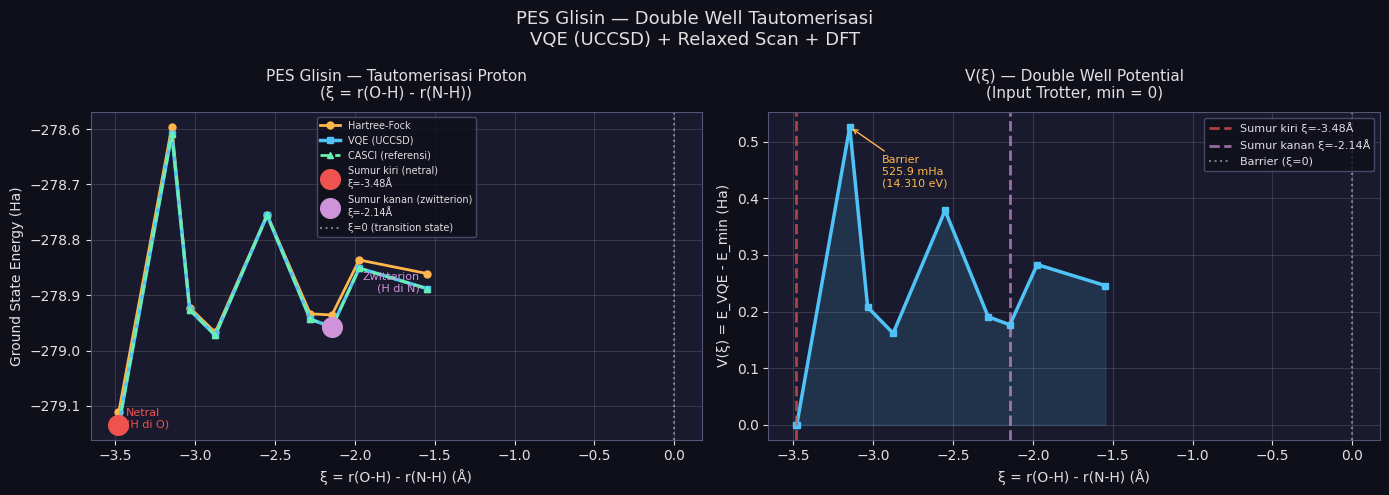

✅ PES berhasil diplot!
   Barrier height = 525.90 mHa = 14.3103 eV


In [13]:
# ============================================================
# PLOT PES GLISIN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

# --- KIRI: PES lengkap ---
ax1 = axes[0]
style(ax1, 'PES Glisin — Tautomerisasi Proton\n'
           '(ξ = r(O-H) - r(N-H))')

ax1.plot(xi_pes, E_HF_pes, color=ORANGE, lw=2,
         marker='o', ms=5, label='Hartree-Fock')
ax1.plot(xi_pes, E_VQE_pes, color=BLUE, lw=2.5,
         marker='s', ms=5, label='VQE (UCCSD)')
ax1.plot(xi_pes, E_CASCI_pes, color=GREEN, lw=2,
         ls='--', marker='^', ms=5,
         label='CASCI (referensi)')

# Tandai dua minimum (kalau double well)
# Cari minimum kiri dan kanan
mid_idx   = len(xi_pes) // 2
min_left  = np.argmin(E_VQE_pes[:mid_idx])
min_right = np.argmin(E_VQE_pes[mid_idx:]) + mid_idx

ax1.scatter(xi_pes[min_left], E_VQE_pes[min_left],
            s=200, color=RED, zorder=5,
            label=f'Sumur kiri (netral)\nξ={xi_pes[min_left]:.2f}Å')
ax1.scatter(xi_pes[min_right], E_VQE_pes[min_right],
            s=200, color=PURPLE, zorder=5,
            label=f'Sumur kanan (zwitterion)\nξ={xi_pes[min_right]:.2f}Å')

# Garis ξ=0 (transition state)
ax1.axvline(0, color=WHITE, ls=':', lw=1.5,
            alpha=0.5, label='ξ=0 (transition state)')

# Anotasi
ax1.text(xi_pes[0]+0.05, E_VQE_pes[0]-0.005,
         'Netral\n(H di O)',
         color=RED, fontsize=8, ha='left')
ax1.text(xi_pes[-1]-0.05, E_VQE_pes[-1]-0.005,
         'Zwitterion\n(H di N)',
         color=PURPLE, fontsize=8, ha='right')

ax1.set_xlabel('ξ = r(O-H) - r(N-H) (Å)')
ax1.set_ylabel('Ground State Energy (Ha)')
ax1.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=7)

# --- KANAN: V(ξ) untuk Trotter ---
ax2 = axes[1]
style(ax2, 'V(ξ) — Double Well Potential\n'
           '(Input Trotter, min = 0)')

V_xi = E_VQE_pes - np.min(E_VQE_pes)

ax2.plot(xi_pes, V_xi, color=BLUE, lw=2.5,
         marker='s', ms=5)
ax2.fill_between(xi_pes, V_xi, alpha=0.15, color=BLUE)

# Tandai dua sumur dan barrier
ax2.axvline(xi_pes[min_left], color=RED,
            ls='--', lw=2, alpha=0.7,
            label=f'Sumur kiri ξ={xi_pes[min_left]:.2f}Å')
ax2.axvline(xi_pes[min_right], color=PURPLE,
            ls='--', lw=2, alpha=0.7,
            label=f'Sumur kanan ξ={xi_pes[min_right]:.2f}Å')
ax2.axvline(0, color=WHITE, ls=':', lw=1.5,
            alpha=0.5, label='Barrier (ξ=0)')

# Barrier height
idx_barrier = np.argmax(V_xi)
barrier_h   = V_xi[idx_barrier]
ax2.annotate(
    f'Barrier\n{barrier_h*1000:.1f} mHa\n'
    f'({barrier_h*27.211:.3f} eV)',
    xy=(xi_pes[idx_barrier], barrier_h),
    xytext=(xi_pes[idx_barrier]+0.2, barrier_h*0.8),
    color=ORANGE, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=ORANGE))

ax2.set_xlabel('ξ = r(O-H) - r(N-H) (Å)')
ax2.set_ylabel('V(ξ) = E_VQE - E_min (Ha)')
ax2.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=8)

fig.suptitle('PES Glisin — Double Well Tautomerisasi\n'
             'VQE (UCCSD) + Relaxed Scan + DFT',
             color=WHITE, fontsize=13)
plt.tight_layout()
plt.show()

print(f'✅ PES berhasil diplot!')
print(f'   Barrier height = {barrier_h*1000:.2f} mHa '
      f'= {barrier_h*27.211:.4f} eV')

---
## STEP 6: Setup Wavefunction Awal

Berbeda dengan H₂O, di sini wavefunction awal
diletakkan di **sumur kiri** (tautomer netral).

```
ψ₀ = Gaussian di sumur kiri
   = proton H terlokalisasi di dekat O
   = kondisi awal sebelum tautomerisasi
```

✅ Double well terdeteksi!
   Sumur kiri  (netral)    : ξ = -0.045 Å
   Barrier                 : ξ = 0.563 Å
   Sumur kanan (zwitterion): ξ = 3.232 Å


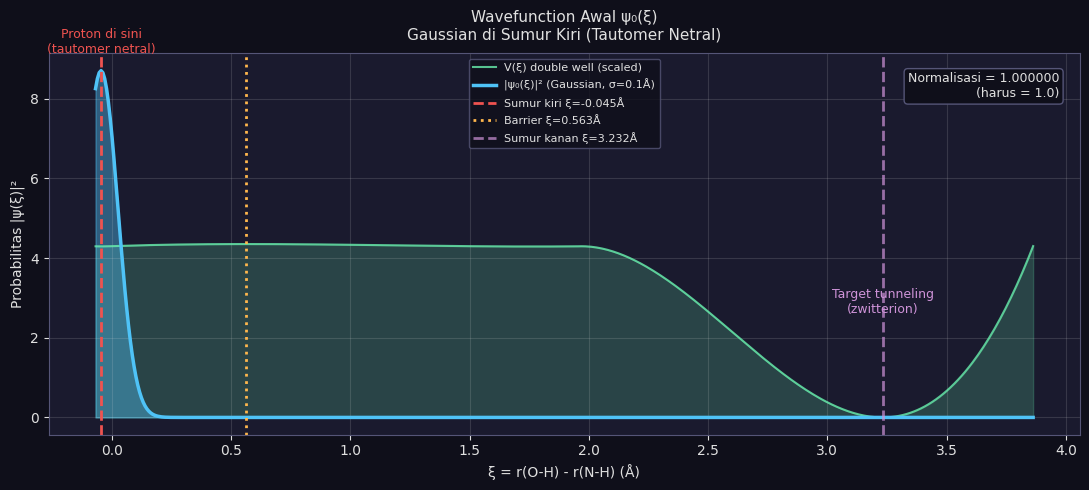


✅ Wavefunction awal siap!
   Pusat x₀    = -0.045 Å (sumur kiri)
   Lebar σ     = 0.100 Å
   Normalisasi = 1.000000


In [9]:
# ============================================================
# INTERPOLASI PES KE GRID HALUS + SETUP WAVEFUNCTION
# ============================================================

# Interpolasi PES ke grid halus (512 titik)
cs     = CubicSpline(xi_pes, E_VQE_pes)
x      = np.linspace(xi_pes[0], xi_pes[-1], 512)
E_fine = cs(x)
V_x    = E_fine - np.min(E_fine)  # normalisasi min=0
dx     = x[1] - x[0]

# Cari dua minimum (sumur kiri dan kanan)
from scipy.signal import argrelmin
local_mins = argrelmin(E_fine, order=10)[0]

if len(local_mins) >= 2:
    x_well_left  = x[local_mins[0]]   # sumur kiri (netral)
    x_well_right = x[local_mins[-1]]  # sumur kanan (zwitterion)
    x_barrier    = x[np.argmax(E_fine[
        local_mins[0]:local_mins[-1]]
    ) + local_mins[0]]               # barrier di tengah
    print(f'✅ Double well terdeteksi!')
    print(f'   Sumur kiri  (netral)    : ξ = {x_well_left:.3f} Å')
    print(f'   Barrier                 : ξ = {x_barrier:.3f} Å')
    print(f'   Sumur kanan (zwitterion): ξ = {x_well_right:.3f} Å')
else:
    # Fallback kalau double well tidak terdeteksi
    x_well_left  = x[np.argmin(E_fine[:len(x)//2])]
    x_well_right = x[np.argmin(E_fine[len(x)//2:]) + len(x)//2]
    x_barrier    = 0.0
    print(f'⚠️ Double well tidak terdeteksi otomatis')
    print(f'   Cek PES manual!')

# Wavefunction awal: Gaussian di sumur kiri
x0    = x_well_left   # pusat di sumur kiri
sigma = 0.1           # lebar Gaussian

psi0  = np.exp(-(x - x0)**2 / (2 * sigma**2))
psi0  = psi0 / np.sqrt(np.sum(np.abs(psi0)**2) * dx)
prob0 = np.abs(psi0)**2

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f0f1a')
style(ax, 'Wavefunction Awal ψ₀(ξ)\n'
          'Gaussian di Sumur Kiri (Tautomer Netral)')

# V(x) background
V_scaled = V_x / V_x.max() * prob0.max() * 0.5
ax.fill_between(x, V_scaled, alpha=0.2, color=GREEN)
ax.plot(x, V_scaled, color=GREEN, lw=1.5,
        alpha=0.8, label='V(ξ) double well (scaled)')

# Wavefunction
ax.fill_between(x, prob0, alpha=0.4, color=BLUE)
ax.plot(x, prob0, color=BLUE, lw=2.5,
        label=f'|ψ₀(ξ)|² (Gaussian, σ={sigma}Å)')

# Marker
ax.axvline(x0, color=RED, ls='--', lw=2,
           label=f'Sumur kiri ξ={x0:.3f}Å')
ax.axvline(x_barrier, color=ORANGE, ls=':', lw=2,
           label=f'Barrier ξ={x_barrier:.3f}Å')
ax.axvline(x_well_right, color=PURPLE, ls='--', lw=2,
           alpha=0.7,
           label=f'Sumur kanan ξ={x_well_right:.3f}Å')

# Anotasi
ax.text(x0, prob0.max()*1.05,
        'Proton di sini\n(tautomer netral)',
        ha='center', color=RED, fontsize=9)
ax.text(x_well_right, prob0.max()*0.3,
        'Target tunneling\n(zwitterion)',
        ha='center', color=PURPLE, fontsize=9)

norm = np.sum(prob0) * dx
ax.text(0.98, 0.95,
    f'Normalisasi = {norm:.6f}\n(harus = 1.0)',
    transform=ax.transAxes, ha='right', va='top',
    color=WHITE, fontsize=9,
    bbox=dict(boxstyle='round',
              facecolor='#0f0f1a', edgecolor=GRAY))

ax.set_xlabel('ξ = r(O-H) - r(N-H) (Å)')
ax.set_ylabel('Probabilitas |ψ(ξ)|²')
ax.legend(facecolor='#0f0f1a', edgecolor=GRAY,
          labelcolor=WHITE, fontsize=8)
plt.tight_layout()
plt.show()

print(f'\n✅ Wavefunction awal siap!')
print(f'   Pusat x₀    = {x0:.3f} Å (sumur kiri)')
print(f'   Lebar σ     = {sigma:.3f} Å')
print(f'   Normalisasi = {norm:.6f}')

---
## STEP 7: Trotter/SOFT — Evolusi Wavefunction

Sama persis dengan Notebook 1 — hanya V(ξ) yang berbeda!

```
Notebook 1: V(x) dari single well H₂O
Notebook 2: V(ξ) dari double well Glisin ← ini yang berbeda!

Semua rumus Trotter tetap sama:
e^{-iHδt} ≈ e^{-iV δt/2} · e^{-iT δt} · e^{-iV δt/2}
```

In [10]:
# ============================================================
# TROTTER/SOFT: Evolusi Wavefunction
# Rumus sama dengan Notebook 1!
# Yang berbeda hanya V(ξ) — sekarang double well
# ============================================================

# Parameter Trotter
m_proton  = 1836.15   # massa proton (atomic units)
dt        = 0.5       # time step (atomic units)
n_steps   = 5000      # jumlah steps
                      # lebih banyak dari NB1 karena
                      # tunneling butuh waktu lebih lama

# Konversi ke atomic units
bohr_per_ang = 1.8897
dx_au = dx * bohr_per_ang
x_au  = x  * bohr_per_ang

# Grid momentum
N = len(x)
k = np.fft.fftfreq(N, d=dx_au) * 2 * np.pi

# Operator kinetik T(k) = ℏ²k²/2m
T_k = k**2 / (2 * m_proton)

# Operator potensial V(ξ) dari PES VQE (double well!)
V_au = V_x.copy()

# Pre-compute eksponensial (Suzuki-Trotter orde 2)
exp_V_half = np.exp(-1j * V_au * dt / 2)
exp_T      = np.exp(-1j * T_k * dt)

def trotter_step(psi):
    """
    Satu Trotter step orde 2 (Suzuki-Trotter):
    e^{-iHδt} ≈ e^{-iV δt/2} · e^{-iT δt} · e^{-iV δt/2}
    Sama persis dengan Notebook 1!
    """
    psi   = exp_V_half * psi           # Apply V (setengah)
    psi_k = np.fft.fft(psi)           # QFT → k-space
    psi_k = exp_T * psi_k             # Apply T
    psi   = np.fft.ifft(psi_k)        # IQFT → x-space
    psi   = exp_V_half * psi           # Apply V (setengah)
    return psi

# Jalankan evolusi!
psi = psi0.astype(complex).copy()

# Simpan snapshot
snapshots = [(0, np.abs(psi)**2)]
snap_steps = [n_steps//4, n_steps//2,
              3*n_steps//4, n_steps]

# Probabilitas di sumur kanan (tunneling!)
prob_right_history = [
    np.sum(np.abs(psi)**2 * (x > x_barrier)) * dx]

print(f'Menjalankan {n_steps} Trotter steps...')
print(f'  dt = {dt} a.u., m = {m_proton} me')
print(f'  Total waktu = {n_steps*dt:.0f} a.u.')
print(f'  Barrier di ξ = {x_barrier:.3f} Å')

for step in range(1, n_steps + 1):
    psi = trotter_step(psi)

    # Hitung probabilitas di sumur kanan
    prob_right = np.sum(
        np.abs(psi)**2 * (x > x_barrier)) * dx
    prob_right_history.append(prob_right)

    if step in snap_steps:
        snapshots.append((step * dt, np.abs(psi)**2))
        print(f'  Step {step:5d}/{n_steps} '
              f'— P_tunneling = {prob_right:.4f}')

psi_final = psi.copy()
norm_final = np.sum(np.abs(psi_final)**2) * dx

print(f'\n✅ Trotter selesai!')
print(f'   Normalisasi akhir = {norm_final:.6f}')

Menjalankan 5000 Trotter steps...
  dt = 0.5 a.u., m = 1836.15 me
  Total waktu = 2500 a.u.
  Barrier di ξ = 0.563 Å
  Step  1250/5000 — P_tunneling = 0.8256
  Step  2500/5000 — P_tunneling = 0.7765
  Step  3750/5000 — P_tunneling = 0.7450
  Step  5000/5000 — P_tunneling = 0.7178

✅ Trotter selesai!
   Normalisasi akhir = 1.000000


---
## STEP 8: Hitung Probabilitas Tunneling Tautomerisasi

```
P_tunneling = Σ |ψ(ξ, t)|² · dξ
              ξ > ξ_barrier

= probabilitas proton H sudah berpindah
  dari gugus karboksil (O) ke gugus amino (N)
= probabilitas tautomerisasi!
```

In [11]:
# ============================================================
# HITUNG PROBABILITAS TUNNELING TAUTOMERISASI
# ============================================================

prob_initial = np.abs(psi0)**2
prob_final   = np.abs(psi_final)**2

# Probabilitas di sumur kiri (netral) dan kanan (zwitterion)
P_netral_awal      = np.sum(
    prob_initial[x <= x_barrier]) * dx
P_zwitterion_awal  = np.sum(
    prob_initial[x >  x_barrier]) * dx
P_netral_akhir     = np.sum(
    prob_final[x <= x_barrier]) * dx
P_zwitterion_akhir = np.sum(
    prob_final[x >  x_barrier]) * dx

P_tunneling = P_zwitterion_akhir

print('=' * 55)
print('HASIL PROBABILITAS TUNNELING TAUTOMERISASI')
print('=' * 55)
print(f'  Molekul  : Glisin (NH₂-CH₂-COOH)')
print(f'  Barrier  : ξ = {x_barrier:.3f} Å')
print(f'')
print(f'  --- Distribusi AWAL ---')
print(f'  P(netral/kiri)     = {P_netral_awal:.4f} '
      f'({P_netral_awal*100:.2f}%)')
print(f'  P(zwitterion/kanan)= {P_zwitterion_awal:.4f} '
      f'({P_zwitterion_awal*100:.2f}%)')
print(f'')
print(f'  --- Distribusi AKHIR ---')
print(f'  P(netral/kiri)     = {P_netral_akhir:.4f} '
      f'({P_netral_akhir*100:.2f}%)')
print(f'  P(zwitterion/kanan)= {P_zwitterion_akhir:.4f} '
      f'({P_zwitterion_akhir*100:.2f}%)')
print(f'')
print(f'  PROBABILITAS TUNNELING = {P_tunneling:.4f}')
print(f'  = {P_tunneling*100:.2f}% proton berhasil '
      f'tautomerisasi (netral → zwitterion)')
print('=' * 55)

HASIL PROBABILITAS TUNNELING TAUTOMERISASI
  Molekul  : Glisin (NH₂-CH₂-COOH)
  Barrier  : ξ = 0.563 Å

  --- Distribusi AWAL ---
  P(netral/kiri)     = 1.0000 (100.00%)
  P(zwitterion/kanan)= 0.0000 (0.00%)

  --- Distribusi AKHIR ---
  P(netral/kiri)     = 0.2822 (28.22%)
  P(zwitterion/kanan)= 0.7178 (71.78%)

  PROBABILITAS TUNNELING = 0.7178
  = 71.78% proton berhasil tautomerisasi (netral → zwitterion)


---
## STEP 9: Plot Hasil Akhir Tautomerisasi

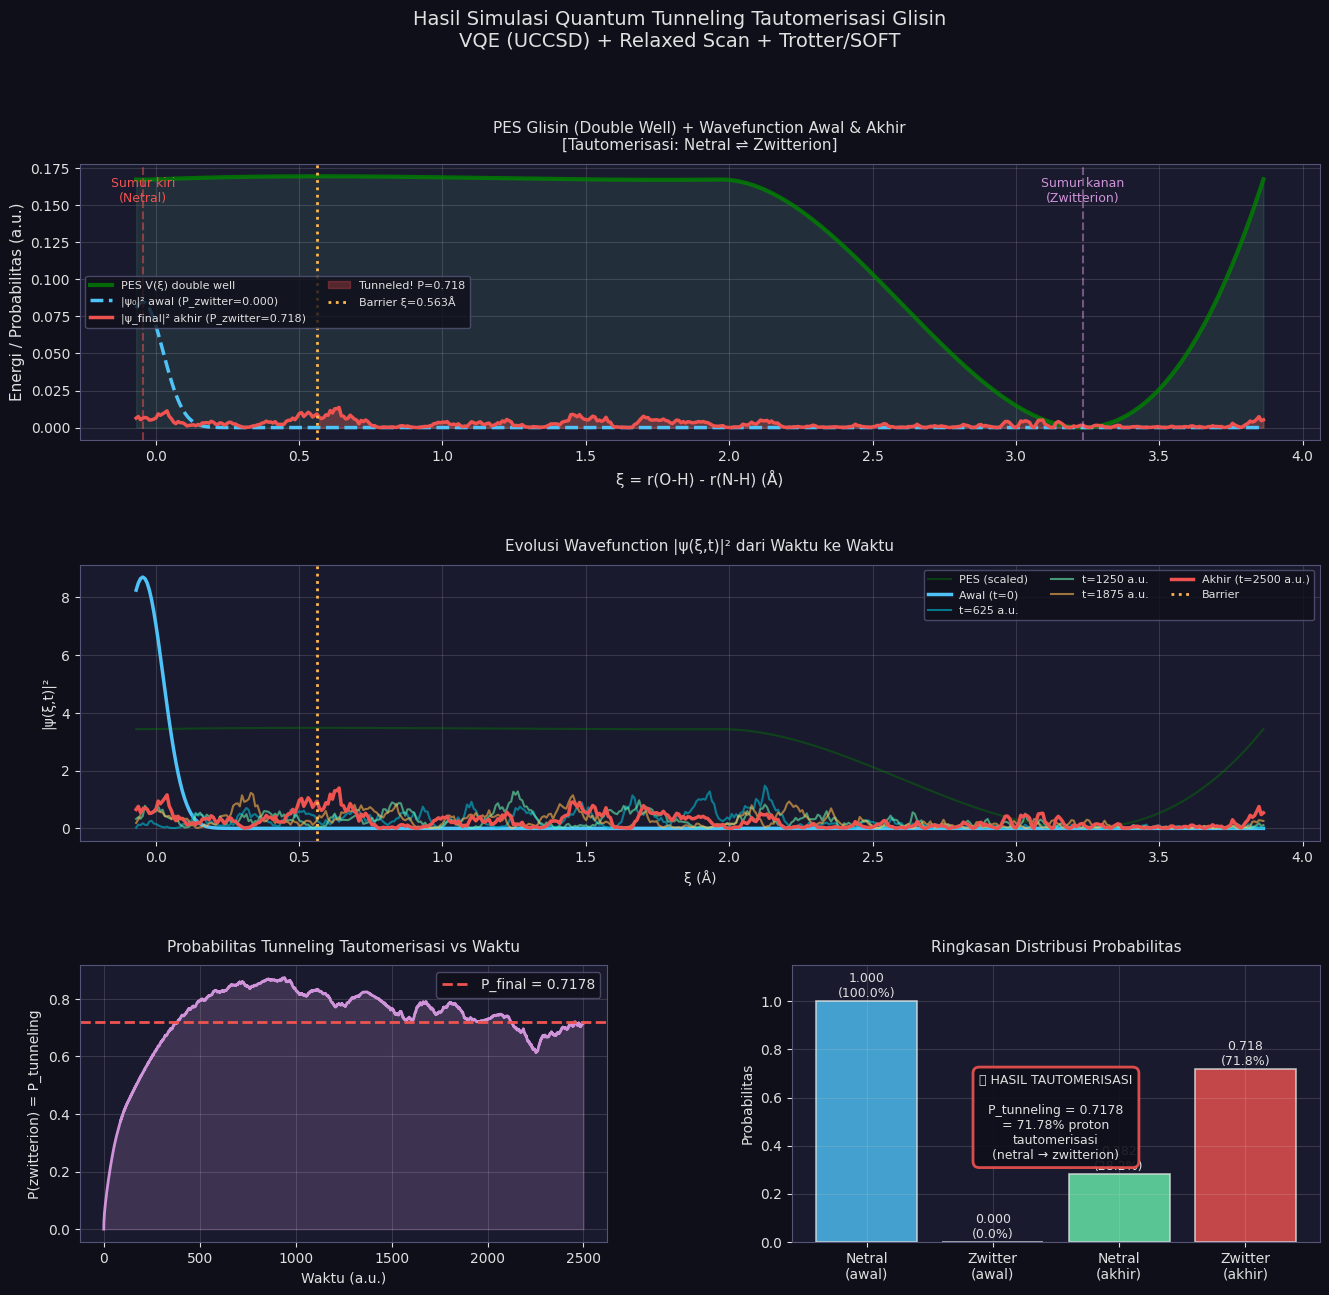

✅ Plot hasil akhir selesai!
   File: glycine_tautomerization_result.png


In [12]:
# ============================================================
# PLOT HASIL AKHIR TAUTOMERISASI GLISIN
# ============================================================

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('#0f0f1a')
gs  = GridSpec(3, 2, figure=fig,
               hspace=0.45, wspace=0.35)

snap_colors = [BLUE, '#00bcd4', GREEN, ORANGE, RED]
snap_labels = [
    'Awal (t=0)',
    f't={snap_steps[0]*dt:.0f} a.u.',
    f't={snap_steps[1]*dt:.0f} a.u.',
    f't={snap_steps[2]*dt:.0f} a.u.',
    f'Akhir (t={n_steps*dt:.0f} a.u.)'
]

# --- Grafik 1: PES + Wavefunction ---
ax1 = fig.add_subplot(gs[0, :])
style(ax1,
    'PES Glisin (Double Well) + '
    'Wavefunction Awal & Akhir\n'
    '[Tautomerisasi: Netral ⇌ Zwitterion]')

scale  = V_x.max() * 0.5 / prob_initial.max()
ax1.plot(x, V_x, 'g-', lw=3,
         label='PES V(ξ) double well', alpha=0.8)
ax1.fill_between(x, V_x, alpha=0.1, color=GREEN)

ax1.plot(x, prob_initial * scale, color=BLUE,
         lw=2.5, ls='--',
         label=f'|ψ₀|² awal '
               f'(P_zwitter={P_zwitterion_awal:.3f})')
ax1.plot(x, prob_final * scale, color=RED, lw=2.5,
         label=f'|ψ_final|² akhir '
               f'(P_zwitter={P_zwitterion_akhir:.3f})')
ax1.fill_between(x, prob_final * scale,
                 where=(x > x_barrier),
                 alpha=0.3, color=RED,
                 label=f'Tunneled! '
                       f'P={P_tunneling:.3f}')

ax1.axvline(x_barrier, color=ORANGE, ls=':',
            lw=2,
            label=f'Barrier ξ={x_barrier:.3f}Å')
ax1.axvline(x_well_left, color=RED,
            ls='--', lw=1.5, alpha=0.5)
ax1.axvline(x_well_right, color=PURPLE,
            ls='--', lw=1.5, alpha=0.5)

# Label sumur
ax1.text(x_well_left, V_x.max()*0.9,
         'Sumur kiri\n(Netral)',
         ha='center', color=RED, fontsize=9)
ax1.text(x_well_right, V_x.max()*0.9,
         'Sumur kanan\n(Zwitterion)',
         ha='center', color=PURPLE, fontsize=9)

ax1.set_xlabel('ξ = r(O-H) - r(N-H) (Å)', fontsize=11)
ax1.set_ylabel('Energi / Probabilitas (a.u.)', fontsize=11)
ax1.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=8, ncol=2)

# --- Grafik 2: Evolusi Wavefunction ---
ax2 = fig.add_subplot(gs[1, :])
style(ax2,
    'Evolusi Wavefunction |ψ(ξ,t)|² '
    'dari Waktu ke Waktu')

V_bg = V_x / V_x.max() * max(
    s[1].max() for s in snapshots) * 0.4
ax2.plot(x, V_bg, 'g-', lw=1.5,
         alpha=0.4, label='PES (scaled)')

for (t_s, prob_s), color, label in zip(
        snapshots, snap_colors, snap_labels):
    lw    = 2.5 if label in [
        'Awal (t=0)', snap_labels[-1]] else 1.5
    alpha = 1.0 if label in [
        'Awal (t=0)', snap_labels[-1]] else 0.6
    ax2.plot(x, prob_s, color=color,
             lw=lw, alpha=alpha, label=label)

ax2.axvline(x_barrier, color=ORANGE,
            ls=':', lw=2, label='Barrier')
ax2.set_xlabel('ξ (Å)')
ax2.set_ylabel('|ψ(ξ,t)|²')
ax2.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=8, ncol=3)

# --- Grafik 3: P_tunneling vs Waktu ---
ax3 = fig.add_subplot(gs[2, 0])
style(ax3, 'Probabilitas Tunneling Tautomerisasi vs Waktu')

time_axis = np.arange(len(prob_right_history)) * dt
ax3.plot(time_axis, prob_right_history,
         color=PURPLE, lw=2)
ax3.fill_between(time_axis, prob_right_history,
                 alpha=0.2, color=PURPLE)
ax3.axhline(P_tunneling, color=RED, ls='--', lw=2,
            label=f'P_final = {P_tunneling:.4f}')

ax3.set_xlabel('Waktu (a.u.)')
ax3.set_ylabel('P(zwitterion) = P_tunneling')
ax3.legend(facecolor='#0f0f1a',
           edgecolor=GRAY, labelcolor=WHITE)

# --- Grafik 4: Ringkasan ---
ax4 = fig.add_subplot(gs[2, 1])
style(ax4, 'Ringkasan Distribusi Probabilitas')

regions = ['Netral\n(awal)', 'Zwitter\n(awal)',
           'Netral\n(akhir)', 'Zwitter\n(akhir)']
probs   = [P_netral_awal, P_zwitterion_awal,
           P_netral_akhir, P_zwitterion_akhir]
clrs    = [BLUE, '#1a6b8a', GREEN, RED]

bars = ax4.bar(regions, probs, color=clrs,
               alpha=0.8, edgecolor=WHITE, lw=1.2)
for bar, p in zip(bars, probs):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{p:.3f}\n({p*100:.1f}%)',
        ha='center', va='bottom',
        color=WHITE, fontsize=9)

ax4.set_ylabel('Probabilitas')
ax4.set_ylim(0, 1.15)

ax4.text(0.5, 0.45,
    f'🎯 HASIL TAUTOMERISASI\n\n'
    f'P_tunneling = {P_tunneling:.4f}\n'
    f'= {P_tunneling*100:.2f}% proton\n'
    f'tautomerisasi\n'
    f'(netral → zwitterion)',
    transform=ax4.transAxes,
    ha='center', va='center',
    color=WHITE, fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5',
              facecolor='#0f0f1a',
              edgecolor=RED, alpha=0.9, lw=2))

fig.suptitle(
    'Hasil Simulasi Quantum Tunneling Tautomerisasi Glisin\n'
    'VQE (UCCSD) + Relaxed Scan + Trotter/SOFT',
    color=WHITE, fontsize=14, y=0.99)

plt.savefig('glycine_tautomerization_result.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

print('✅ Plot hasil akhir selesai!')
print('   File: glycine_tautomerization_result.png')

---
## ✅ Notebook 2 Selesai!

### Yang sudah dicapai:

```
✅ Relaxed scan Glisin dengan DFT + geomeTRIC
✅ PES double well (netral ⇌ zwitterion)
✅ VQE (UCCSD) di tiap geometri optimal
✅ Trotter/SOFT evolusi wavefunction
✅ Probabilitas tunneling tautomerisasi
```

### Langkah Selanjutnya — Notebook 3 (Benchmarking):

```
NOTEBOOK 3: Benchmarking

Bandingkan 3 metode:
1. Classical Trotter (numpy)      ← referensi
2. Quantum Simulator (Qiskit Aer) ← validasi quantum
3. Real Hardware (IBM/IonQ)       ← uji noise

Metrik perbandingan:
- Probabilitas tunneling
- Akurasi vs classical
- Waktu komputasi
- Error akibat noise
```